## Library

In [2]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import cv2
import numpy as np
import mediapipe as mp
from glob import glob
from matplotlib import pyplot as plt
from retinaface import RetinaFace
import tensorflow as tf

import importlib
import pandas as pd
from IPython.display import display

## Media pipe setup

In [3]:
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from urllib.request import urlretrieve

model_path = "face_landmarker.task"
if not os.path.exists(model_path):
    urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task",
        model_path,
    )

base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_faces=1,
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False,
    )
face_mesh = vision.FaceLandmarker.create_from_options(options)

## Data setup

In [4]:
TEST_ROOT = "../dataset/face_shape/testing_set"
class_names = sorted([
    d for d in os.listdir(TEST_ROOT)
    if os.path.isdir(os.path.join(TEST_ROOT, d))
])

PAIR_IDX = 0

class_to_images = {}
for cls in class_names:
    patterns = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]
    files = []
    for p in patterns:
        files.extend(glob(os.path.join(TEST_ROOT, cls, p)))
    class_to_images[cls] = sorted(files)

max_pairs = min((len(v) for v in class_to_images.values()), default=0)
if max_pairs == 0:
    raise ValueError("Tidak ada gambar di testing_set.")
if PAIR_IDX < 0 or PAIR_IDX >= max_pairs:
    raise ValueError(f"PAIR_IDX harus di rentang 0..{max_pairs-1}")

selected_samples = {cls: class_to_images[cls][PAIR_IDX] for cls in class_names}
print("TensorFlow:", tf.__version__)
print("Kelas:", class_names)
print(f"Menampilkan pair index: {PAIR_IDX} dari total {max_pairs} pair")

TensorFlow: 2.21.0
Kelas: ['Heart', 'Oblong', 'Oval', 'Round', 'Square']
Menampilkan pair index: 0 dari total 400 pair


## Extracting face insight using MediaPipe

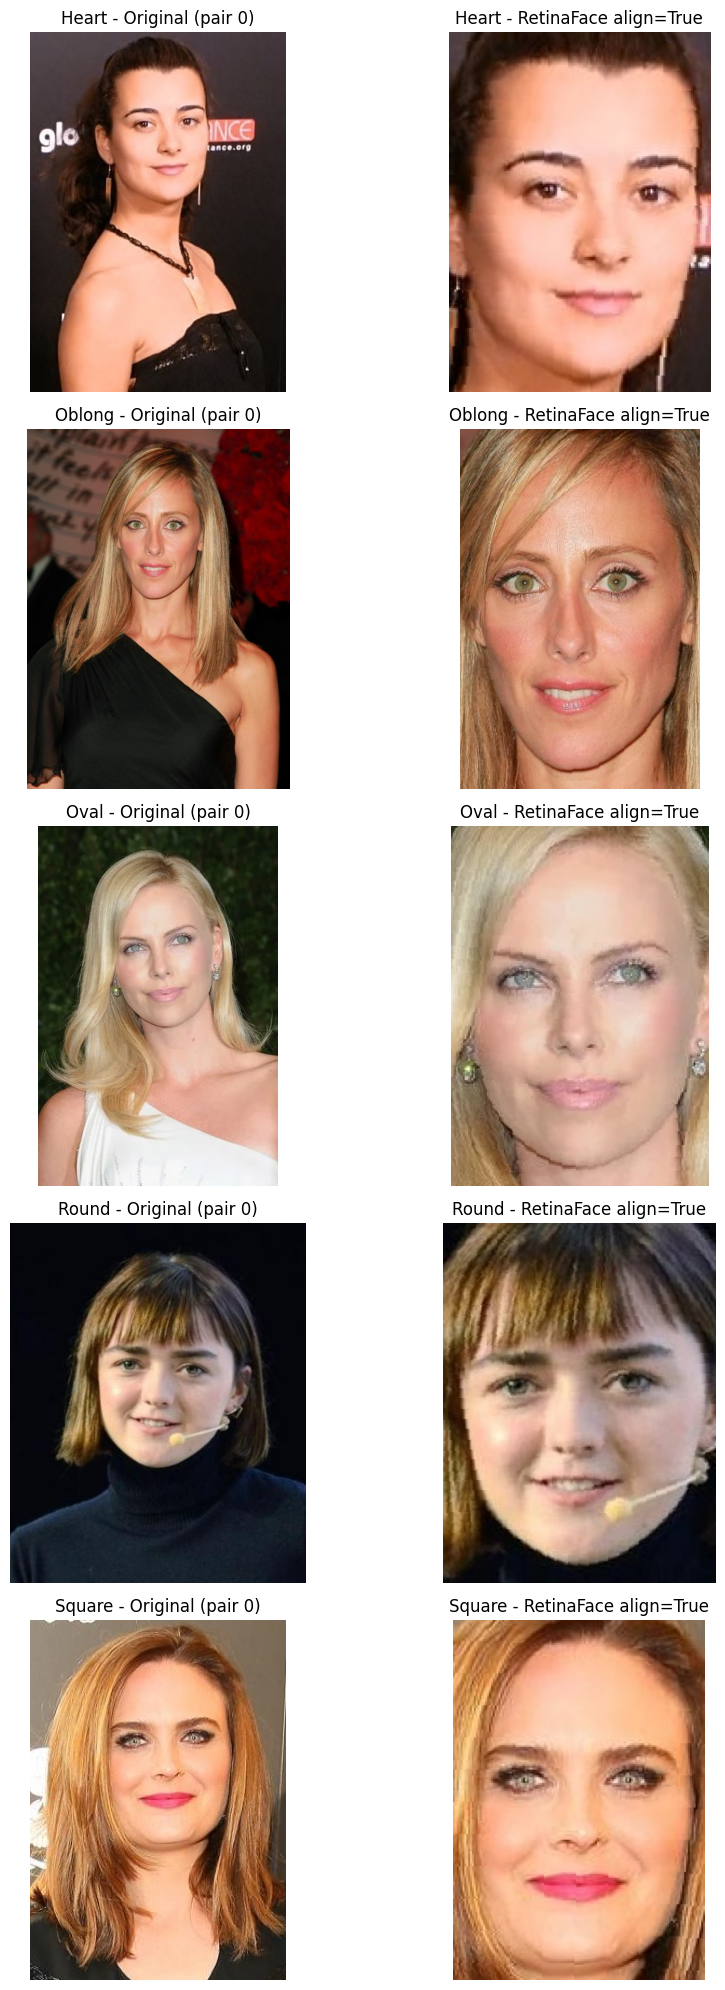

In [5]:
flow_results = {}

for cls in class_names:
    img_path = selected_samples[cls]
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    faces = RetinaFace.extract_faces(img_path=img_path, align=True, expand_face_area=15)
    aligned_face = faces[0] if len(faces) > 0 else None

    flow_results[cls] = {
        "img_path": img_path,
        "original_rgb": img_rgb,
        "aligned_face": aligned_face,
    }

rows = len(class_names)
fig, axes = plt.subplots(rows, 2, figsize=(10, 4 * rows), squeeze=False)

for r, cls in enumerate(class_names):
    axes[r, 0].imshow(flow_results[cls]["original_rgb"])
    axes[r, 0].set_title(f"{cls} - Original (pair {PAIR_IDX})")
    axes[r, 0].axis("off")

    face = flow_results[cls]["aligned_face"]
    if face is not None:
        axes[r, 1].imshow(face)
        axes[r, 1].set_title(f"{cls} - RetinaFace align=True")
    else:
        axes[r, 1].text(0.5, 0.5, "Face not detected", ha="center", va="center")
        axes[r, 1].set_title(f"{cls} - RetinaFace align=True")
    axes[r, 1].axis("off")

plt.tight_layout()
plt.show()

## Landmark

In [6]:
landmark_results = {}

for cls in class_names:
    aligned_face = flow_results[cls]["aligned_face"]
    if aligned_face is None:
        landmark_results[cls] = None
        print(f"{cls}: wajah tidak terdeteksi di flow align.")
        continue

    if aligned_face.dtype != np.uint8:
        aligned_face = np.clip(aligned_face, 0, 255).astype(np.uint8)

    candidates = [
        ("crop_as_is", aligned_face),
        ("crop_bgr_to_rgb", cv2.cvtColor(aligned_face, cv2.COLOR_BGR2RGB)),
    ]

    best = None
    for candidate_name, candidate_img in candidates:
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=candidate_img)
        result = face_mesh.detect(mp_image)
        if result.face_landmarks:
            points_468 = np.array(
                [(lm.x, lm.y, lm.z) for lm in result.face_landmarks[0][:468]],
                dtype=np.float32,
            )
            best = {
                "candidate_name": candidate_name,
                "image": candidate_img,
                "points_468": points_468,
            }
            break

    landmark_results[cls] = best
    if best is None:
        print(f"{cls}: landmark gagal terdeteksi.")
    else:
        print(f"{cls}: {len(best['points_468'])} titik ({best['candidate_name']})")

Heart: 468 titik (crop_bgr_to_rgb)
Oblong: 468 titik (crop_bgr_to_rgb)
Oval: 468 titik (crop_bgr_to_rgb)
Round: 468 titik (crop_bgr_to_rgb)
Square: 468 titik (crop_bgr_to_rgb)


In [7]:
landmark_results['Heart']['points_468']

array([[ 0.59836125,  0.7207999 , -0.08879597],
       [ 0.623927  ,  0.6296811 , -0.20367497],
       [ 0.60717374,  0.65519965, -0.10087287],
       ...,
       [ 0.6533495 ,  0.47293818, -0.03109601],
       [ 0.8370722 ,  0.44777268,  0.080267  ],
       [ 0.871247  ,  0.43407422,  0.08522911]],
      shape=(468, 3), dtype=float32)

## Helpers to reconstruct an ordered face-oval cycle from MediaPipe edges

In [8]:
def edges_to_ordered_cycle(edges, start=None):
    """
    edges: iterable of (i, j) pairs forming a single cycle (each node degree=2)
    returns ordered list of vertex indices along the cycle.
    """
    adj = {}
    for a, b in edges:
        adj.setdefault(a, []).append(b)
        adj.setdefault(b, []).append(a)

    if start is None:
        start = min(adj.keys())

    cycle = [start]
    prev = None
    cur = start
    while True:
        nbs = adj[cur]
        nxt = nbs[0] if nbs[0] != prev else nbs[1]
        if nxt == start:
            break
        cycle.append(nxt)
        prev, cur = cur, nxt
        if len(cycle) > len(adj) + 5:
            raise RuntimeError("Cycle reconstruction failed; are edges a single loop?")
    return cycle, adj


def normalize_by_interocular(P):
    """
    P: (468, 3) points
    returns centered, PCA-aligned, scaled points + scale factor
    """
    P = P.astype(np.float64)
    P0 = P - P.mean(axis=0, keepdims=True)

    # PCA alignment (SVD on centered points)
    _, _, Vt = np.linalg.svd(P0, full_matrices=False)
    R = Vt.T
    X = P0 @ R  # aligned

    # Fix sign so left/right is consistent using outer eye corners:
    # Right eye contour includes 33; left eye contour includes 263 in MediaPipe constants.
    # If your camera is mirrored, you may swap the sign condition.
    if X[33, 0] < X[263, 0]:
        X[:, 0] *= -1.0

    # Scale by inter-ocular distance (outer corners approx: 33 and 263)
    iod = np.linalg.norm(X[33] - X[263]) + 1e-9
    X /= iod
    return X, iod


def band_width(X_cycle, t_cycle, t_lo, t_hi):
    mask = (t_cycle >= t_lo) & (t_cycle <= t_hi)
    xs = X_cycle[mask, 0]
    if xs.size < 2:
        return np.nan
    return float(xs.max() - xs.min())


def angle_at_point(a, b, c):
    """
    Angle ABC in radians where points are vectors.
    """
    ba = a - b
    bc = c - b
    denom = (np.linalg.norm(ba) * np.linalg.norm(bc)) + 1e-12
    cosang = np.dot(ba, bc) / denom
    cosang = np.clip(cosang, -1.0, 1.0)
    return float(np.arccos(cosang))


def polyline_curvature_stats(X_cycle_xy):
    """
    Discrete turning-angle curvature proxy on a closed polyline (N,2).
    Returns mean turning angle, std, max turning angle.
    """
    N = X_cycle_xy.shape[0]
    angs = []
    for i in range(N):
        p_prev = X_cycle_xy[(i - 1) % N]
        p = X_cycle_xy[i]
        p_next = X_cycle_xy[(i + 1) % N]
        ang = angle_at_point(p_prev, p, p_next)  # turning angle at p
        angs.append(ang)
    angs = np.array(angs)
    return float(angs.mean()), float(angs.std()), float(angs.max())

## Feature Extractor

In [9]:
def extract_features(points468, facemesh_face_oval_edges):
    """
    points468: (468,3) float array (MediaPipe-style x,y normalized; z relative)
    facemesh_face_oval_edges: iterable of (i,j) edges from MediaPipe FACEMESH_FACE_OVAL

    Returns a dict of geometric features.
    """
    X, _ = normalize_by_interocular(points468)

    cycle_ids, adj = edges_to_ordered_cycle(facemesh_face_oval_edges, start=10)
    X_cycle = X[np.array(cycle_ids)]

    y = X_cycle[:, 1]
    y_top, y_bot = y.min(), y.max()
    t = (y - y_top) / (y_bot - y_top + 1e-12)  # 0=top, 1=bottom

    # widths
    forehead_w = band_width(X_cycle, t, 0.10, 0.25)
    cheek_w = band_width(X_cycle, t, 0.35, 0.60)
    jaw_w = band_width(X_cycle, t, 0.70, 0.90)

    face_len = float(y_bot - y_top)
    face_ar = float(face_len / (cheek_w + 1e-12))  # length-to-width ratio

    # Chin sharpness via angle at chin index (often 152 on the oval cycle)
    # Find chin index position in the cycle_ids list
    chin_idx = 152
    if chin_idx in adj:
        nbs = adj[chin_idx]  # two neighbors in contour graph
        a = X[nbs[0], :2]
        b = X[chin_idx, :2]
        c = X[nbs[1], :2]
        chin_angle = angle_at_point(a, b, c)
    else:
        chin_angle = np.nan

    # Contour curvature stats (xy plane)
    curv_mean, curv_std, curv_max = polyline_curvature_stats(X_cycle[:, :2])

    # Side-depth consistency: quick proxy assuming x=0 is midsagittal after PCA.
    # Compare depth (z) distribution left vs right by mirroring x.
    left = X[X[:, 0] > 0]
    right = X[X[:, 0] < 0]
    # summarize depth stats; you can replace this with true symmetric pairing
    z_left = left[:, 2] if left.size else np.array([np.nan])
    z_right = right[:, 2] if right.size else np.array([np.nan])
    side_depth_consistency = float(np.abs(np.nanmean(z_left) - np.nanmean(z_right)))

    # Ratios used in landmark-based face shape work:
    r_top = float(forehead_w / (cheek_w + 1e-12))
    r_bot = float(jaw_w / (cheek_w + 1e-12))
    r_top_minus_bot = float(r_top - r_bot)

    return {
        "forehead_width": forehead_w,
        "cheekbone_width": cheek_w,
        "jaw_width": jaw_w,
        "chin_angle_rad": chin_angle,
        "face_length": face_len,
        "face_aspect_ratio_len_over_width": face_ar,
        "contour_turning_mean": curv_mean,
        "contour_turning_std": curv_std,
        "contour_turning_max": curv_max,
        "side_depth_consistency_proxy": side_depth_consistency,
        "RTop": r_top,
        "RBot": r_bot,
        "RTop_minus_RBot": r_top_minus_bot,
    }

In [18]:
# N Sampel
SAMPLES_PER_CLASS = 50
patterns = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]

face_oval_edges = None
try:
    face_mesh_mod = importlib.import_module("mediapipe.python.solutions.face_mesh")
    face_oval_edges = list(face_mesh_mod.FACEMESH_FACE_OVAL)
except Exception:
    pass

if face_oval_edges is None:
    face_oval_cycle = [
        10, 338, 297, 332, 284, 251, 389, 356, 454, 323, 361, 288,
        397, 365, 379, 378, 400, 377, 152, 148, 176, 149, 150, 136,
        172, 58, 132, 93, 234, 127, 162, 21, 54, 103, 67, 109,
    ]
    face_oval_edges = list(
        zip(face_oval_cycle, face_oval_cycle[1:] + [face_oval_cycle[0]])
    )

def detect_points_468_from_path(img_path):
    """Deteksi 468 landmark dari 1 gambar memakai flow RetinaFace -> MediaPipe."""
    try:
        faces = RetinaFace.extract_faces(
            img_path=img_path,
            align=True,
            expand_face_area=15,
        )
    except Exception as e:
        return None, f"retinaface_error: {e}"

    if len(faces) == 0 or faces[0] is None:
        return None, "no_face"

    aligned_face = faces[0]
    if aligned_face.dtype != np.uint8:
        aligned_face = np.clip(aligned_face, 0, 255).astype(np.uint8)

    candidates = [
        ("crop_as_is", aligned_face),
        ("crop_bgr_to_rgb", cv2.cvtColor(aligned_face, cv2.COLOR_BGR2RGB)),
    ]

    for candidate_name, candidate_img in candidates:
        try:
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=candidate_img)
            result = face_mesh.detect(mp_image)
        except Exception:
            continue

        if result.face_landmarks:
            points_468 = np.array(
                [(lm.x, lm.y, lm.z) for lm in result.face_landmarks[0][:468]],
                dtype=np.float32,
            )
            return points_468, candidate_name

    return None, "landmark_not_found"


records = []
failed_records = []

for cls in class_names:
    cls_files = []
    for p in patterns:
        cls_files.extend(glob(os.path.join(TEST_ROOT, cls, p)))
    cls_files = sorted(cls_files)[:SAMPLES_PER_CLASS]

    for sample_idx, img_path in enumerate(cls_files, start=1):
        points_468, source = detect_points_468_from_path(img_path)

        if points_468 is None:
            failed_records.append(
                {
                    "class": cls,
                    "sample_no": sample_idx,
                    "img_path": img_path,
                    "reason": source,
                }
            )
            continue

        features = extract_features(points_468, face_oval_edges)
        records.append(
            {
                "class": cls,
                "sample_no": sample_idx,
                "img_path": img_path,
                "landmark_source": source,
                **features,
            }
        )

df_features = pd.DataFrame(records)
df_failed = pd.DataFrame(failed_records)

print(f"Total data sukses ekstraksi: {len(df_features)}")
print(f"Total data gagal ekstraksi : {len(df_failed)}")
if not df_failed.empty:
    print("Contoh gagal:")
    display(df_failed.head(10))

if df_features.empty:
    raise ValueError("Tidak ada data fitur yang berhasil diekstrak.")

display(df_features.head(10))

Total data sukses ekstraksi: 250
Total data gagal ekstraksi : 0


,class,sample_no,img_path,landmark_source,forehead_width,cheekbone_width,jaw_width,chin_angle_rad,face_length,face_aspect_ratio_len_over_width,contour_turning_mean,contour_turning_std,contour_turning_max,side_depth_consistency_proxy,RTop,RBot,RTop_minus_RBot
0,Heart,1,../dataset/face_shape/testing_set\Heart\heart ...,crop_bgr_to_rgb,1.511628,1.610731,1.444991,3.048179,1.360228,0.844479,2.967060,0.096638,3.139042,0.012606,0.938473,0.897103,0.041371
1,Heart,2,../dataset/face_shape/testing_set\Heart\heart ...,crop_bgr_to_rgb,1.511628,1.610731,1.444991,3.048179,1.360228,0.844479,2.967060,0.096638,3.139042,0.012606,0.938473,0.897103,0.041371
2,Heart,3,../dataset/face_shape/testing_set\Heart\heart ...,crop_bgr_to_rgb,1.508822,1.593027,1.454829,3.026832,1.356213,0.851344,2.967060,0.084652,3.075220,0.015436,0.947142,0.913248,0.033894
3,Heart,4,../dataset/face_shape/testing_set\Heart\heart ...,crop_bgr_to_rgb,1.508822,1.593027,1.454829,3.026832,1.356213,0.851344,2.967060,0.084652,3.075220,0.015436,0.947142,0.913248,0.033894
4,Heart,5,../dataset/face_shape/testing_set\Heart\heart ...,crop_bgr_to_rgb,1.341069,1.580699,1.486395,3.095040,1.431239,0.905447,2.967060,0.104732,3.104722,0.004196,0.848403,0.940341,-0.091938
5,Heart,6,../dataset/face_shape/testing_set\Heart\heart ...,crop_bgr_to_rgb,1.341069,1.580699,1.486395,3.095040,1.431239,0.905447,2.967060,0.104732,3.104722,0.004196,0.848403,0.940341,-0.091938
6,Heart,7,../dataset/face_shape/testing_set\Heart\heart ...,crop_bgr_to_rgb,1.280312,1.554872,1.493128,3.122578,1.420991,0.913895,2.967060,0.130346,3.138272,0.006183,0.823420,0.960290,-0.136870
7,Heart,8,../dataset/face_shape/testing_set\Heart\heart ...,crop_bgr_to_rgb,1.280312,1.554872,1.493128,3.122578,1.420991,0.913895,2.967060,0.130346,3.138272,0.006183,0.823420,0.960290,-0.136870
8,Heart,9,../dataset/face_shape/testing_set\Heart\heart ...,crop_bgr_to_rgb,1.460185,1.563738,1.438943,3.001366,1.317899,0.842788,2.965704,0.107492,3.127467,0.005276,0.933779,0.920195,0.013584
9,Heart,10,../dataset/face_shape/testing_set\Heart\heart ...,crop_bgr_to_rgb,1.460185,1.563738,1.438943,3.001366,1.317899,0.842788,2.965704,0.107492,3.127467,0.005276,0.933779,0.920195,0.013584


## Tabel Perbandingan per Kelas
Ringkasan statistik per kelas untuk setiap fitur utama (mean, std, min, max).

In [20]:
feature_cols = [
    c for c in df_features.columns
    if c not in ["class", "sample_no", "img_path", "landmark_source"]
]

stats_table = (
    df_features.groupby("class")[feature_cols]
    .agg(["mean", "std", "min", "max"])
    .round(4)
)

print("Ukuran tabel statistik:", stats_table.shape)
display(stats_table)

Ukuran tabel statistik: (5, 52)


forehead_width                         cheekbone_width                  \
                 mean     std     min     max            mean     std     min   
class                                                                           
Heart          1.4311  0.0955  1.2039  1.5916          1.5661  0.0334  1.4618   
Oblong         1.4045  0.1092  1.1693  1.5965          1.5799  0.0488  1.4887   
Oval           1.4065  0.0590  1.3125  1.5080          1.5631  0.0385  1.4789   
Round          1.4726  0.1214  1.1186  1.6697          1.5877  0.0648  1.4771   
Square         1.4572  0.1128  1.1528  1.6236          1.5743  0.0605  1.4646   

               jaw_width          ...    RTop            RBot                  \
           max      mean     std  ...     min     max    mean     std     min   
class                             ...                                           
Heart   1.6117    1.4216  0.0833  ...  0.7695  0.9956  0.9079  0.0524  0.7850   
Oblong  1.6722    1.4531  0.0861  ...  0.7365  1.0132  0.9202  0.0549  0.8014   
Oval    1.6184    1.4484  0.0649  ...  0.8313  0.9764  0.9265  0.0313  0.8541   
Round   1.7312    1.4206  0.1024  ...  0.7164  1.0337  0.8948  0.0543  0.7870   
Square  1.6894    1.4262  0.1338  ...  0.7391  1.0339  0.9050  0.0658  0.7601   

               RTop_minus_RBot                          
           max            mean     std     min     max  
class                                                   
Heart   1.0001          0.0058  0.1036 -0.2306  0.2106  
Oblong  1.0314         -0.0313  0.1112 -0.2949  0.2118  
Oval    0.9759         -0.0264  0.0656 -0.1236  0.1065  
Round   1.0223          0.0326  0.1163 -0.3059  0.2467  
Square  0.9975          0.0214  0.1354 -0.2505  0.2738  

[5 rows x 52 columns]

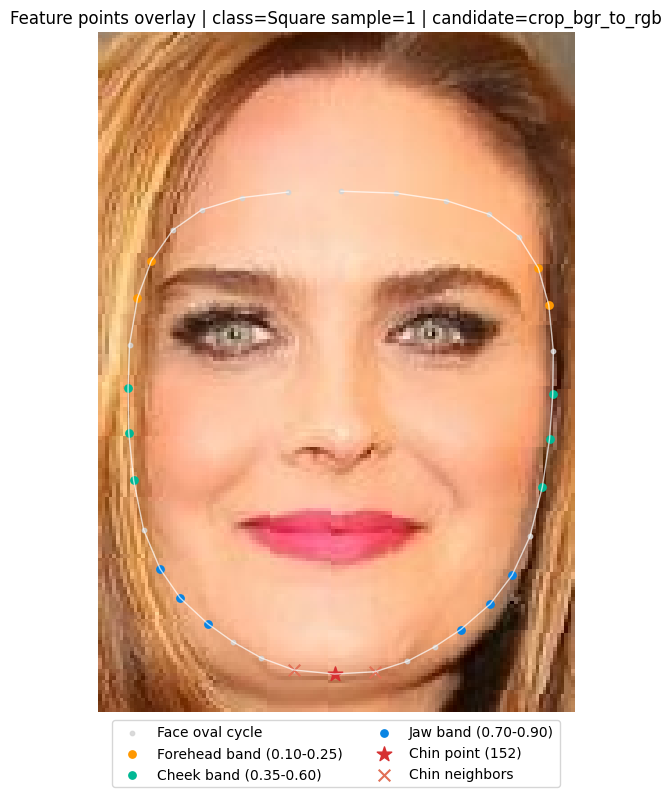

Ringkasan titik yang dipakai:
- Forehead points: 4
- Cheek points   : 6
- Jaw points     : 6
- Chin neighbors : 2


In [26]:
# Visual debug titik yang dipakai untuk extraction feature (diletakkan setelah Cell 18)
VIS_CLASS = "Square"  # ganti: Heart / Oblong / Oval / Round / Square
VIS_SAMPLE_NO = 1       # sample ke-n dalam kelas (mulai dari 1)

if df_features.empty:
    raise ValueError("df_features kosong. Jalankan Cell 16 terlebih dulu.")

if VIS_CLASS not in class_names:
    raise ValueError(f"VIS_CLASS '{VIS_CLASS}' tidak ada di class_names: {class_names}")

sel = df_features[
    (df_features["class"] == VIS_CLASS) &
    (df_features["sample_no"] == VIS_SAMPLE_NO)
].copy()

if sel.empty:
    print("Sample spesifik tidak ada, fallback ke sample pertama kelas tersebut.")
    sel = df_features[df_features["class"] == VIS_CLASS].head(1).copy()

vis_row = sel.iloc[0]
vis_img_path = vis_row["img_path"]

# Re-run deteksi agar dapat gambar kandidat + 468 landmark
faces = RetinaFace.extract_faces(img_path=vis_img_path, align=True, expand_face_area=15)
if len(faces) == 0 or faces[0] is None:
    raise ValueError("Face tidak terdeteksi pada sample ini.")

aligned_face = faces[0]
if aligned_face.dtype != np.uint8:
    aligned_face = np.clip(aligned_face, 0, 255).astype(np.uint8)

cand_list = [
    ("crop_as_is", aligned_face),
    ("crop_bgr_to_rgb", cv2.cvtColor(aligned_face, cv2.COLOR_BGR2RGB)),
]

vis_candidate_name = None
vis_img = None
vis_points = None

for cand_name, cand_img in cand_list:
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=cand_img)
    r = face_mesh.detect(mp_image)
    if r.face_landmarks:
        vis_candidate_name = cand_name
        vis_img = cand_img
        vis_points = np.array([(lm.x, lm.y, lm.z) for lm in r.face_landmarks[0][:468]], dtype=np.float32)
        break

if vis_points is None:
    raise ValueError("Landmark tidak ditemukan untuk sample visualisasi.")

# Reproduksi titik yang dipakai di extract_features
X, _ = normalize_by_interocular(vis_points)
cycle_ids, adj = edges_to_ordered_cycle(face_oval_edges, start=10)
cycle_ids = np.array(cycle_ids, dtype=np.int32)
X_cycle = X[cycle_ids]

y = X_cycle[:, 1]
y_top, y_bot = y.min(), y.max()
t = (y - y_top) / (y_bot - y_top + 1e-12)

mask_forehead = (t >= 0.10) & (t <= 0.25)
mask_cheek = (t >= 0.35) & (t <= 0.60)
mask_jaw = (t >= 0.70) & (t <= 0.90)

forehead_ids = cycle_ids[mask_forehead]
cheek_ids = cycle_ids[mask_cheek]
jaw_ids = cycle_ids[mask_jaw]

chin_idx = 152
chin_nb = np.array(adj.get(chin_idx, []), dtype=np.int32)

h, w = vis_img.shape[:2]
px = vis_points[:, 0] * w
py = vis_points[:, 1] * h

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))

# kontur oval dasar
ax.plot(px[cycle_ids], py[cycle_ids], color="white", linewidth=1.0, alpha=0.7)
ax.scatter(px[cycle_ids], py[cycle_ids], s=10, c="lightgray", alpha=0.8, label="Face oval cycle")

# band fitur
ax.scatter(px[forehead_ids], py[forehead_ids], s=28, c="#ff9800", label="Forehead band (0.10-0.25)")
ax.scatter(px[cheek_ids], py[cheek_ids], s=28, c="#00b894", label="Cheek band (0.35-0.60)")
ax.scatter(px[jaw_ids], py[jaw_ids], s=28, c="#0984e3", label="Jaw band (0.70-0.90)")

# titik chin untuk angle
if chin_idx < len(px):
    ax.scatter(px[chin_idx], py[chin_idx], s=120, c="#d63031", marker="*", label="Chin point (152)")
if chin_nb.size > 0:
    ax.scatter(px[chin_nb], py[chin_nb], s=70, c="#e17055", marker="x", label="Chin neighbors")

ax.set_title(
    f"Feature points overlay | class={vis_row['class']} sample={int(vis_row['sample_no'])} | candidate={vis_candidate_name}"
    )
ax.axis("off")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=True)
plt.tight_layout()
plt.show()

print("Ringkasan titik yang dipakai:")
print(f"- Forehead points: {len(forehead_ids)}")
print(f"- Cheek points   : {len(cheek_ids)}")
print(f"- Jaw points     : {len(jaw_ids)}")
print(f"- Chin neighbors : {len(chin_nb)}")

## Analisis Perbandingan Mean Antar Kelas
Mean per kelas dibandingkan dengan mean global untuk melihat fitur mana yang paling membedakan tiap kelas.

In [21]:
class_mean = df_features.groupby("class")[feature_cols].mean()
global_mean = df_features[feature_cols].mean()

delta_from_global = (class_mean - global_mean).round(4)
abs_delta_rank = delta_from_global.abs().mean(axis=0).sort_values(ascending=False)

print("Perbandingan mean kelas vs mean global:")
display(delta_from_global)

print("Ranking fitur paling membedakan kelas (berdasarkan rata-rata |delta|):")
display(abs_delta_rank.to_frame("avg_abs_delta"))

Perbandingan mean kelas vs mean global:


,forehead_width,cheekbone_width,jaw_width,chin_angle_rad,face_length,face_aspect_ratio_len_over_width,contour_turning_mean,contour_turning_std,contour_turning_max,side_depth_consistency_proxy,RTop,RBot,RTop_minus_RBot
class,,,,,,,,,,,,,
Heart,-0.0033,-0.0081,-0.0123,-0.0053,0.0090,0.0100,0.0001,0.0003,0.0001,0.0006,0.0024,-0.0030,0.0054
Oblong,-0.0299,0.0057,0.0191,0.0037,0.0352,0.0189,-0.0002,-0.0035,-0.0004,-0.0010,-0.0224,0.0093,-0.0317
Oval,-0.0279,-0.0111,0.0144,0.0295,0.0229,0.0208,0.0002,0.0015,-0.0031,0.0001,-0.0112,0.0156,-0.0268
Round,0.0382,0.0135,-0.0133,-0.0229,-0.0167,-0.0174,0.0002,-0.0048,-0.0021,-0.0005,0.0161,-0.0161,0.0322
Square,0.0228,0.0001,-0.0078,-0.0050,-0.0504,-0.0323,-0.0003,0.0065,0.0055,0.0008,0.0151,-0.0059,0.0210


Ranking fitur paling membedakan kelas (berdasarkan rata-rata |delta|):


,avg_abs_delta
face_length,0.02684
forehead_width,0.02442
RTop_minus_RBot,0.02342
face_aspect_ratio_len_over_width,0.01988
RTop,0.01344
jaw_width,0.01338
chin_angle_rad,0.01328
RBot,0.00998
cheekbone_width,0.00770
contour_turning_std,0.00332


## Analisis Separability Fitur
Mengukur rasio variasi antar-kelas terhadap variasi intra-kelas (semakin tinggi, semakin diskriminatif).

In [22]:
between_var = df_features.groupby("class")[feature_cols].mean().var(ddof=0)
within_var = df_features.groupby("class")[feature_cols].var(ddof=0).mean()
separability = (between_var / (within_var + 1e-12)).sort_values(ascending=False)

separability_table = pd.DataFrame({
    "between_class_var": between_var,
    "within_class_var": within_var,
    "separability_ratio": between_var / (within_var + 1e-12),
}).sort_values("separability_ratio", ascending=False).round(6)

print("Ranking separability fitur:")
display(separability_table)

top_features = separability.index[:4].tolist()
print("Top fitur untuk divisualisasikan:", top_features)

Ranking separability fitur:


,between_class_var,within_class_var,separability_ratio
face_aspect_ratio_len_over_width,0.000448,0.001686,0.265971
face_length,0.000932,0.004312,0.216070
chin_angle_rad,0.000293,0.002607,0.112197
contour_turning_std,0.000016,0.000178,0.090417
forehead_width,0.000733,0.010187,0.071962
RTop,0.000224,0.003553,0.062962
RTop_minus_RBot,0.000646,0.011620,0.055576
contour_turning_mean,0.000000,0.000001,0.053129
RBot,0.000127,0.002746,0.046108
contour_turning_max,0.000009,0.000276,0.032310


Top fitur untuk divisualisasikan: ['face_aspect_ratio_len_over_width', 'face_length', 'chin_angle_rad', 'contour_turning_std']


## Visualisasi Distribusi Fitur per Kelas
Boxplot untuk fitur yang paling separable agar perbedaan antar kelas lebih mudah terlihat.

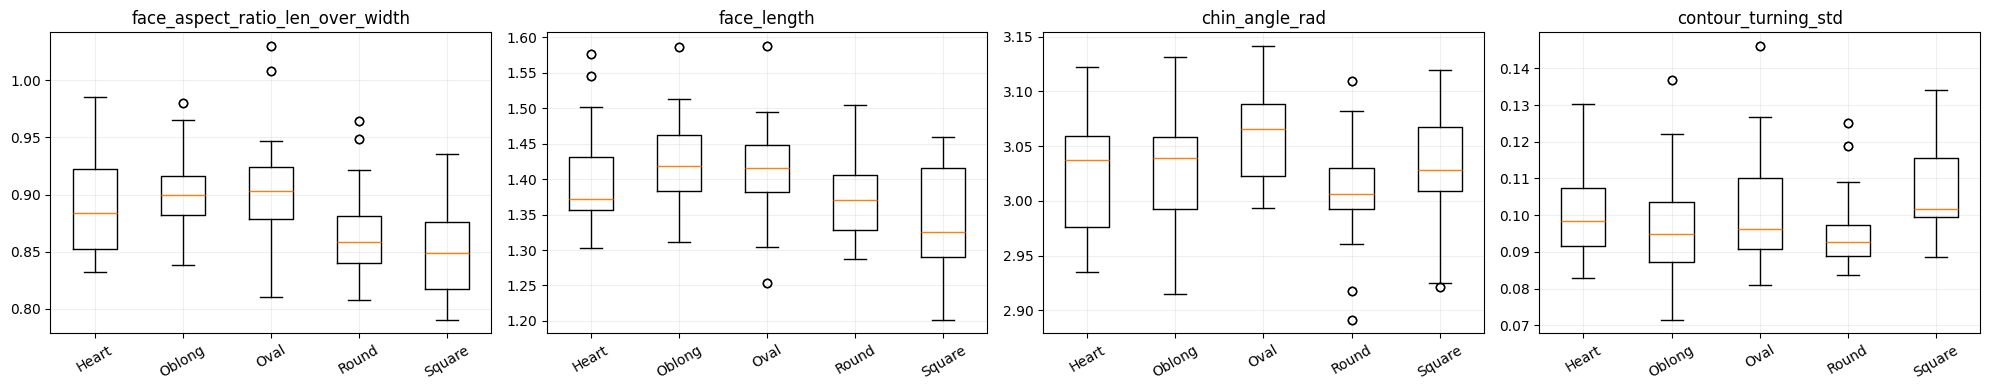

In [23]:
if len(top_features) == 0:
    raise ValueError("Tidak ada fitur untuk divisualisasikan.")

n = len(top_features)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), squeeze=False)

for i, feat in enumerate(top_features):
    ax = axes[0, i]
    grouped = [
        df_features.loc[df_features["class"] == cls, feat].dropna().values
        for cls in class_names
    ]
    ax.boxplot(grouped, labels=class_names, showfliers=True)
    ax.set_title(feat)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Sanity Check Terhadap Morfologi Wajah
Ringkasan ini membantu cek apakah nilai fitur selaras dengan karakter umum bentuk wajah (square, round, heart, oblong, oval).

In [24]:
core_feats = [
    "jaw_width",
    "forehead_width",
    "cheekbone_width",
    "face_aspect_ratio_len_over_width",
    "chin_angle_rad",
    "RTop_minus_RBot",
]

class_core = df_features.groupby("class")[core_feats].mean().round(4)
print("Mean fitur inti per kelas:")
display(class_core)

def rank_desc(s):
    return s.sort_values(ascending=False).index.tolist()

print("\nRanking kelas per fitur (desc):")
for feat in core_feats:
    print(f"- {feat}: {rank_desc(class_core[feat])}")

# Heuristic cepat (bukan ground-truth classifier)
heuristic = {}
if "Square" in class_core.index:
    sq = class_core.loc["Square"]
    heuristic["Square"] = {
        "jaw_vs_global": float(sq["jaw_width"] - class_core["jaw_width"].mean()),
        "r_top_minus_bot": float(sq["RTop_minus_RBot"]),
        "chin_angle_vs_global": float(sq["chin_angle_rad"] - class_core["chin_angle_rad"].mean()),
    }
if "Heart" in class_core.index:
    ht = class_core.loc["Heart"]
    heuristic["Heart"] = {
        "r_top_minus_bot": float(ht["RTop_minus_RBot"]),
        "jaw_vs_global": float(ht["jaw_width"] - class_core["jaw_width"].mean()),
    }
if "Oblong" in class_core.index:
    ob = class_core.loc["Oblong"]
    heuristic["Oblong"] = {
        "aspect_ratio_vs_global": float(ob["face_aspect_ratio_len_over_width"] - class_core["face_aspect_ratio_len_over_width"].mean()),
    }
if "Round" in class_core.index:
    rd = class_core.loc["Round"]
    heuristic["Round"] = {
        "aspect_ratio_vs_global": float(rd["face_aspect_ratio_len_over_width"] - class_core["face_aspect_ratio_len_over_width"].mean()),
    }

print("\nHeuristic summary:")
display(pd.DataFrame(heuristic).T.round(4))

Mean fitur inti per kelas:


,jaw_width,forehead_width,cheekbone_width,face_aspect_ratio_len_over_width,chin_angle_rad,RTop_minus_RBot
class,,,,,,
Heart,1.4216,1.4311,1.5661,0.8931,3.0275,0.0058
Oblong,1.4531,1.4045,1.5799,0.9020,3.0365,-0.0313
Oval,1.4484,1.4065,1.5631,0.9039,3.0623,-0.0264
Round,1.4206,1.4726,1.5877,0.8656,3.0099,0.0326
Square,1.4262,1.4572,1.5743,0.8508,3.0278,0.0214



Ranking kelas per fitur (desc):
- jaw_width: ['Oblong', 'Oval', 'Square', 'Heart', 'Round']
- forehead_width: ['Round', 'Square', 'Heart', 'Oval', 'Oblong']
- cheekbone_width: ['Round', 'Oblong', 'Square', 'Heart', 'Oval']
- face_aspect_ratio_len_over_width: ['Oval', 'Oblong', 'Heart', 'Round', 'Square']
- chin_angle_rad: ['Oval', 'Oblong', 'Square', 'Heart', 'Round']
- RTop_minus_RBot: ['Round', 'Square', 'Heart', 'Oval', 'Oblong']

Heuristic summary:


,jaw_vs_global,r_top_minus_bot,chin_angle_vs_global,aspect_ratio_vs_global
Square,-0.0078,0.0214,-0.005,NaN
Heart,-0.0124,0.0058,NaN,NaN
Oblong,NaN,NaN,NaN,0.0189
Round,NaN,NaN,NaN,-0.0175


In [17]:
print("Jumlah sampel sukses per kelas:")
display(df_features.groupby("class").size().rename("n_success").to_frame())

if not df_failed.empty:
    print("Jumlah sampel gagal per kelas:")
    display(df_failed.groupby("class").size().rename("n_failed").to_frame())
else:
    print("Tidak ada sampel gagal.")

Jumlah sampel sukses per kelas:


,n_success
class,
Heart,10
Oblong,10
Oval,10
Round,10
Square,10


Tidak ada sampel gagal.
